In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from sklearn.linear_model import LinearRegression
from rich.box import ROUNDED
from rich.console import Console
from rich.panel import Panel
from rich.table import Table
from rich.terminal_theme import TerminalTheme

In [55]:
# style settings 
plt.rcParams['font.family'] = 'DejaVu Sans'

In [56]:
# load the dataset
data = pd.read_csv('psychology_sales_dataset.csv')

In [57]:
pd.set_option('display.max_columns', None) 
print("Sample data:")
data.sample(3)

Sample data:


,customer_id,age,gender,city,education_level,occupation,stress_level,anxiety_score,self_esteem,impulsiveness,optimism_score,life_satisfaction,social_media_dependency,weekly_site_visits,total_orders,average_order_value,total_spent,campaign_exposure,discount_received,loyalty_points,monthly_purchase_amount
413168,513169,48,Male,Karaj,Master,Analyst,6.32,NaN,6.29,7.01,6.00,6.05,5.24,20,7,124.26,869.79,8,10.02,131.14,130.32
99389,199390,52,Male,Shiraz,Master,Engineer,4.17,3.65,6.20,2.29,8.91,8.85,3.01,14,10,78.50,784.96,5,13.26,68.16,67.69
170901,270902,32,Female,Karaj,High School,Engineer,6.36,6.74,2.97,5.05,5.30,5.30,4.90,29,11,143.22,1575.44,4,5.01,50.44,151.66


In [58]:
# import the classes from the classes folder and reload them to ensure the latest changes are reflected
import importlib
import classes.data_info_display
import classes.missing_values_analyzer
import classes.outlier_detector
 
importlib.reload(classes.data_info_display)
importlib.reload(classes.missing_values_analyzer)
importlib.reload(classes.outlier_detector)
 
from classes.data_info_display import DataInfoDisplay
from classes.missing_values_analyzer import MissingValuesAnalyzer
from classes.outlier_detector import OutlierDetector
 
print("Classes successfully reloaded")

Classes successfully reloaded


In [59]:
# reload the classes to reflect recent edits
# %load_ext autoreload
# %autoreload 2

In [60]:
# display data information using the DataInfoDisplay class
data_display = DataInfoDisplay(data=data)   
data_display.display()

                               Data Info                               
╭─────────────────────────┬──────────┬─────────┬─────────┬────────────╮
│ Column                  │ Non-Null │ Unique  │  Dtype  │ Sample     │
├─────────────────────────┼──────────┼─────────┼─────────┼────────────┤
│ customer_id             │ 550,000  │ 550,000 │  int64  │ 100001     │
│ age                     │ 550,000  │   58    │  int64  │ 38         │
│ gender                  │ 550,000  │    2    │ object  │ Male       │
│ city                    │ 550,000  │    6    │ object  │ Karaj      │
│ education_level         │ 550,000  │    4    │ object  │ PhD        │
│ occupation              │ 533,500  │    6    │ object  │ Freelancer │
│ stress_level            │ 550,000  │   901   │ float64 │ 5.2        │
│ anxiety_score           │ 517,104  │  1,373  │ float64 │ 5.88       │
│ self_esteem             │ 528,000  │   901   │ float64 │ 2.29       │
│ impulsiveness           │ 550,000  │   901   │ float64 │ 7.14       │
│ optimism_score          │ 550,000  │   901   │ float64 │ 6.93       │
│ life_satisfaction       │ 550,000  │   901   │ float64 │ 4.79       │
│ social_media_dependency │ 550,000  │   901   │ float64 │ 6.72       │
│ weekly_site_visits      │ 550,000  │   208   │  int64  │ 24         │
│ total_orders            │ 550,000  │   34    │  int64  │ 7          │
│ average_order_value     │ 550,000  │ 19,708  │ float64 │ 82.04      │
│ total_spent             │ 550,000  │ 203,504 │ float64 │ 574.26     │
│ campaign_exposure       │ 550,000  │   22    │  int64  │ 7          │
│ discount_received       │ 550,000  │  3,638  │ float64 │ 2.07       │
│ loyalty_points          │ 539,000  │ 34,699  │ float64 │ 102.15     │
│ monthly_purchase_amount │ 550,000  │ 27,145  │ float64 │ 150.54     │
╰─────────────────────────┴──────────┴─────────┴─────────┴────────────╯
                            Memory: 187.82 MB                          

  ➤ Rows          550,000  
  ➤ Columns            21  

In [61]:
HTML_THEME = TerminalTheme(
    (18, 18, 18),
    (230, 230, 230),
    [
        (0, 0, 0), (205, 49, 49), (13, 188, 121), (229, 229, 16),
        (36, 114, 200), (188, 63, 188), (17, 168, 205), (229, 229, 229),
    ],
    [
        (102, 102, 102), (241, 76, 76), (35, 209, 139), (245, 245, 67),
        (59, 142, 234), (214, 112, 214), (41, 184, 219), (255, 255, 255),
    ],
)
 
ACCENT  = "#A784B6"
HEADER  = "#842958"
WARNING = "#E0A458"
ERROR   = "#C44536"
VALUE   = "#E8E8E8"
BORDER  = "#5A5A5A"
 
 
def check_aov_consistency(
    data: pd.DataFrame,
    total_col: str = "total_spent",
    orders_col: str = "total_orders",
    aov_col: str = "average_order_value",
    id_col: str = "customer_id",
    tolerance: float = 0.05,
    title: str | None = None,
    save_path: str | None = None,
) -> pd.DataFrame:
    data = data.copy()
    console = Console(record=save_path is not None, width=120)
 
    safe_orders = data[orders_col].replace(0, np.nan)
    data["_expected_aov"] = data[total_col] / safe_orders
    relative_diff = (data[aov_col] - data["_expected_aov"]).abs() / data["_expected_aov"].abs()
    data["_aov_mismatch"] = relative_diff > tolerance
 
    total      = len(data)
    skipped    = data["_expected_aov"].isna().sum()
    checkable  = total - skipped
    mismatches = int(data["_aov_mismatch"].fillna(False).sum())
    consistent = checkable - mismatches
 
    if title:
        console.print(Panel(f"[bold {ACCENT}]{title}[/bold {ACCENT}]", border_style=BORDER, padding=(0, 2)))
 
    table = Table(
        title=f"Sanity Check: {aov_col} vs. {total_col} / {orders_col}",
        box=ROUNDED, title_style=f"bold {ACCENT}", header_style=HEADER, border_style=BORDER,
    )
    table.add_column("Check", style="bold")
    table.add_column("Count", justify="right", style=VALUE)
    table.add_column("Share", justify="right", style=VALUE)
 
    table.add_row("Total rows",                            f"{total:,}",      "100.0%")
    table.add_row(f"[{WARNING}]Skipped (0 orders)[/]",    f"{skipped:,}",    f"{skipped / total:.1%}")
    table.add_row(f"[{ACCENT}]Consistent (≤{tolerance:.0%})[/]", f"{consistent:,}", f"{consistent / total:.1%}")
    table.add_row(f"[bold {ERROR}]Mismatched[/]",          f"{mismatches:,}", f"{mismatches / total:.1%}")
    console.print(table)
 
    if mismatches > 0:
        worst = (
            data.assign(_diff_pct=relative_diff)
            .loc[data["_aov_mismatch"].fillna(False)]
            .nlargest(5, "_diff_pct")
        )
        s = Table(
            title="Largest Mismatches (top 5)",
            box=ROUNDED, title_style=f"bold {WARNING}", header_style=HEADER, border_style=BORDER,
        )
        for c in ["ID", "Reported Total", "Orders", "Reported AOV", "Expected AOV", "Diff"]:
            s.add_column(c, justify="right", style=VALUE)
        for _, row in worst.iterrows():
            s.add_row(
                str(row[id_col]), f"{row[total_col]:,.2f}", f"{int(row[orders_col])}",
                f"{row[aov_col]:,.2f}", f"{row['_expected_aov']:,.2f}", f"{row['_diff_pct']:.1%}",
            )
        console.print(s)
 
    if save_path:
        suffix = Path(save_path).suffix.lower()
        if suffix == ".html":   console.save_html(save_path, theme=HTML_THEME)
        elif suffix == ".svg":  console.save_svg(save_path, title=title or "Sanity Check")
        else:                   console.save_text(save_path)
 
    return data

In [62]:
data = check_aov_consistency(
    data,
    title="Average Order Value — Sanity Check",
    save_path="Report/aov_sanity_check.html",
)

╭──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│  Average Order Value — Sanity Check                                                                                  │
╰──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

  Sanity Check: average_order_value vs.  
       total_spent / total_orders        
╭────────────────────┬─────────┬────────╮
│ Check              │   Count │  Share │
├────────────────────┼─────────┼────────┤
│ Total rows         │ 550,000 │ 100.0% │
│ Skipped (0 orders) │  35,486 │   6.5% │
│ Consistent (≤5%)   │ 513,396 │  93.3% │
│ Mismatched         │   1,118 │   0.2% │
╰────────────────────┴─────────┴────────╯

                         Largest Mismatches (top 5)                          
╭────────┬────────────────┬────────┬──────────────┬──────────────┬──────────╮
│     ID │ Reported Total │ Orders │ Reported AOV │ Expected AOV │     Diff │
├────────┼────────────────┼────────┼──────────────┼──────────────┼──────────┤
│ 486342 │          48.70 │      4 │    11,051.77 │        12.18 │ 90674.3% │
│ 179052 │         256.69 │     13 │    13,536.66 │        19.75 │ 68456.1% │
│ 250574 │         106.80 │      5 │    13,400.78 │        21.36 │ 62637.7% │
│ 391005 │          20.00 │      2 │     6,159.98 │        10.00 │ 61499.8% │
│ 608771 │         147.33 │      7 │    10,630.36 │        21.05 │ 50407.4% │
╰────────┴────────────────┴────────┴──────────────┴──────────────┴──────────╯

In [63]:
# Drop helper columns — no longer needed
data.drop(columns=["_expected_aov", "_aov_mismatch"], inplace=True)

### Missing values

In [64]:
# analyze missing values using the MissingValuesAnalyzer class
analyzer = MissingValuesAnalyzer(data=data)
analyzer.display_detailed_report()

📊 MISSING VALUES ANALYSIS REPORT

============================================================

            📈 Overall Statistics            
╭─────────────────────────────┬─────────────╮
│ Metric                      │       Value │
├─────────────────────────────┼─────────────┤
│ Total Cells in Dataset      │  11,550,000 │
│ Columns with Missing Values │ 4 out of 21 │
│ Total Missing Values        │      82,396 │
│ Total Missing Percentage    │       0.71% │
╰─────────────────────────────┴─────────────╯

                        🔍 Missing Values by Column                         
╭────────────────┬───────────────┬───────────────┬───────────┬─────────────╮
│ Column Name    │   Data Type   │ Missing Count │ Missing % │ Non-Missing │
├────────────────┼───────────────┼───────────────┼───────────┼─────────────┤
│ anxiety_score  │    Numeric    │    32,896     │   5.98%   │   517,104   │
│ self_esteem    │    Numeric    │    22,000     │   4.00%   │   528,000   │
│ occupation     │ Object/String │    16,500     │   3.00%   │   533,500   │
│ loyalty_points │    Numeric    │    11,000     │   2.00%   │   539,000   │
╰────────────────┴───────────────┴───────────────┴───────────┴─────────────╯

                                               💡 Recommendations                                                
╭────────────────┬───────────┬──────────┬───────────────────────────────────────────────────────────────────────╮
│ Column         │ Missing % │ Severity │ Recommended Action                                                    │
├────────────────┼───────────┼──────────┼───────────────────────────────────────────────────────────────────────┤
│ anxiety_score  │   6.0%    │ Moderate │ Impute with median (robust to outliers) or use regression imputation  │
│ self_esteem    │   4.0%    │   Low    │ Low impact: impute with mean/median/mode or drop affected rows safely │
│ occupation     │   3.0%    │   Low    │ Low impact: impute with mean/median/mode or drop affected rows safely │
│ loyalty_points │   2.0%    │   Low    │ Low impact: impute with mean/median/mode or drop affected rows safely │
╰────────────────┴───────────┴──────────┴───────────────────────────────────────────────────────────────────────╯

🗑️  90 row(s) (0.02% of dataset) have 3+ missing values.

   Decide whether to drop these rows: `df.drop(index=analyzer.get_rows_above_threshold()['Row_Index'])`

In [65]:
print("Step 2.1: drop rows with three or more missing values")
analyzer.get_rows_above_threshold().to_csv("missing_three_or_more.csv", index=False)
data = data.drop(index=analyzer.get_rows_above_threshold()['Row_Index'])

Step 2.1: drop rows with three or more missing values


In [66]:
data.corr(numeric_only=True)['anxiety_score'].sort_values(ascending=False)

anxiety_score              1.000000
stress_level               0.815509
monthly_purchase_amount    0.504964
total_spent                0.167747
loyalty_points             0.139159
average_order_value        0.026750
impulsiveness              0.004353
age                        0.000494
customer_id                0.000300
weekly_site_visits        -0.000084
total_orders              -0.000549
social_media_dependency   -0.001279
discount_received         -0.001445
campaign_exposure         -0.002019
self_esteem               -0.646410
life_satisfaction         -0.701306
optimism_score            -0.792288
Name: anxiety_score, dtype: float64

In [67]:
print("Step 2.2: impute 'anxiety_score' with linear regression")
features = ['stress_level', 'optimism_score', 'life_satisfaction']
know   = data[data['anxiety_score'].notna() & data[features].notna().all(axis=1)]
unknow = data[data['anxiety_score'].isna()  & data[features].notna().all(axis=1)]

Step 2.2: impute 'anxiety_score' with linear regression


In [68]:
model = LinearRegression()
model.fit(know[features], know['anxiety_score'])
data.loc[unknow.index, 'anxiety_score'] = model.predict(unknow[features])
print(f"Remaining NaN: {data['anxiety_score'].isna().sum()}")

Remaining NaN: 0


In [69]:
print("Step 2.3: impute 'self_esteem' with linear regression")
features = ['stress_level', 'life_satisfaction', 'optimism_score']
know   = data[data['self_esteem'].notna() & data[features].notna().all(axis=1)]
unknow = data[data['self_esteem'].isna()  & data[features].notna().all(axis=1)]

Step 2.3: impute 'self_esteem' with linear regression


In [70]:
model = LinearRegression()
model.fit(know[features], know['self_esteem'])
data.loc[unknow.index, 'self_esteem'] = model.predict(unknow[features])
print(f"Remaining NaN: {data['self_esteem'].isna().sum()}")

Remaining NaN: 0


In [71]:
print("Step 2.4: impute 'occupation' → 'Unknown'")
data['occupation'] = data['occupation'].fillna('Unknown')
print(f"Remaining NaN: {data['occupation'].isna().sum()}")

Step 2.4: impute 'occupation' → 'Unknown'


Remaining NaN: 0


In [72]:
print("Step 2.5: impute 'loyalty_points' → median")
data['loyalty_points'] = data['loyalty_points'].fillna(data['loyalty_points'].median())
print(f"Remaining NaN: {data['loyalty_points'].isna().sum()}")

Step 2.5: impute 'loyalty_points' → median
Remaining NaN: 0


### Outliers

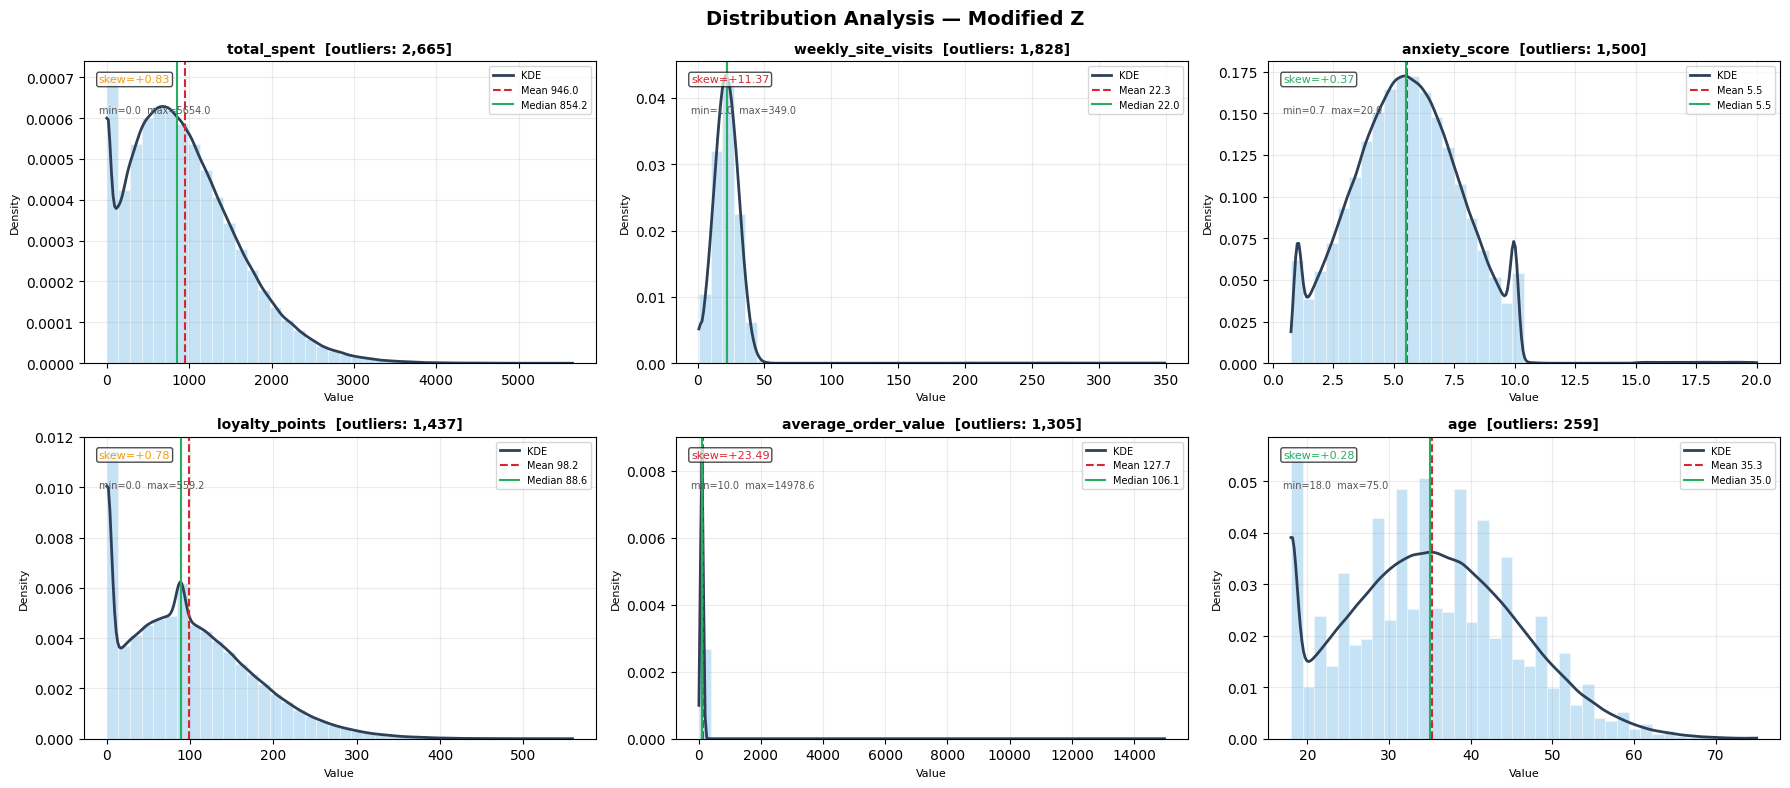

In [73]:
detector = OutlierDetector(data = data)
detector.plot_distributions()

In [74]:
detector.display_report()

📊 OUTLIER DETECTION REPORT

======================================================================

Dataset : 549,910 rows × 21 columns   |   Numeric : 17   |   Method : Modified Z

======================================================================

            📈 Overall Statistics            
╭────────────────────────────┬──────────────╮
│ Metric                     │        Value │
├────────────────────────────┼──────────────┤
│ Total numeric columns      │           17 │
│ Columns with outliers      │ 10 out of 17 │
│ Total outlier count        │        9,231 │
│ Overall outlier percentage │        0.10% │
│ Avg outliers per column    │       543.00 │
╰────────────────────────────┴──────────────╯

                           🎯 Outliers by Column                           
╭────┬─────────────────────────┬───────┬────────────┬──────────┬──────────╮
│ #  │ Column                  │ Count │ Percentage │ Skewness │ Severity │
├────┼─────────────────────────┼───────┼────────────┼──────────┼──────────┤
│ 1  │ total_spent             │ 2,665 │      0.48% │  +0.83   │ 🔵 MINOR │
│ 2  │ weekly_site_visits      │ 1,828 │      0.33% │  +11.37  │ 🔵 MINOR │
│ 3  │ anxiety_score           │ 1,500 │      0.27% │  +0.37   │ 🔵 MINOR │
│ 4  │ loyalty_points          │ 1,437 │      0.26% │  +0.78   │ 🔵 MINOR │
│ 5  │ average_order_value     │ 1,305 │      0.24% │  +23.49  │ 🔵 MINOR │
│ 6  │ age                     │   259 │      0.05% │  +0.28   │ 🔵 MINOR │
│ 7  │ discount_received       │   110 │      0.02% │  +0.15   │ 🔵 MINOR │
│ 8  │ campaign_exposure       │    80 │      0.01% │  +0.01   │ 🔵 MINOR │
│ 9  │ total_orders            │    23 │      0.00% │  +0.25   │ 🔵 MINOR │
│ 10 │ monthly_purchase_amount │    24 │      0.00% │  +0.00   │ 🔵 MINOR │
╰────┴─────────────────────────┴───────┴────────────┴──────────┴──────────╯

                                             🔬 Distribution Diagnosis                                             
╭─────────────────────────┬─────────────────────┬──────────┬────────────┬─────────────────────────────────────────╮
│ Column                  │      Min → Max      │ Skewness │ Normality  │ Diagnosis                               │
├─────────────────────────┼─────────────────────┼──────────┼────────────┼─────────────────────────────────────────┤
│ customer_id             │ 100001.0 → 650000.0 │  -0.00   │ Non-normal │ ✓ Distribution looks healthy            │
│ age                     │     18.0 → 75.0     │  +0.28   │ Non-normal │ ✓ Distribution looks healthy            │
│ stress_level            │     1.0 → 10.0      │  +0.00   │ Non-normal │ ✓ Distribution looks healthy            │
│ anxiety_score           │     0.7 → 20.0      │  +0.37   │ Non-normal │ ✓ Distribution looks healthy            │
│ self_esteem             │     -0.8 → 10.1     │  +0.24   │ Non-normal │ ✓ Distribution looks healthy            │
│ impulsiveness           │     1.0 → 10.0      │  +0.08   │ Non-normal │ ✓ Distribution looks healthy            │
│ optimism_score          │     1.0 → 10.0      │  -0.06   │ Non-normal │ ✓ Distribution looks healthy            │
│ life_satisfaction       │     1.0 → 10.0      │  +0.06   │ Non-normal │ ✓ Distribution looks healthy            │
│ social_media_dependency │     1.0 → 10.0      │  -0.00   │ Non-normal │ ✓ Distribution looks healthy            │
│ weekly_site_visits      │     1.0 → 349.0     │  +11.37  │ Non-normal │ ⚠️  High skew — outlier method may       │
│                         │                     │          │            │ over-flag. Consider log-transform or    │
│                         │                     │          │            │ IQR with wider fence.                   │
│ total_orders            │     0.0 → 33.0      │  +0.25   │ Non-normal │ ✓ Distribution looks healthy            │
│ average_order_value     │   10.0 → 14978.6    │  +23.49  │ Non-normal │ ⚠️  High skew — outlier method may       │
│                         │                     │          │            │ over-flag. Consider log-transform or    │
│                         │                     │          │            │ IQR with wider fence.                   │
│ total_spent             │    0.0 → 5654.0     │  +0.83   │ Non-normal │ ℹ️  Moderate skew — verify flagged       │
│                         │                     │          │            │ values are genuine outliers before      │
│                         │                     │          │            │ acting.                                 │
│ campaign_exposure       │     0.0 → 21.0      │  +0.01   │ Non-normal │ ✓ Distribution looks healthy            │
│ discount_received       │     0.0 → 42.2      │  +0.15   │ Non-normal │ ✓ Distribution looks healthy            │
│ loyalty_points          │     0.0 → 559.2     │  +0.78   │ Non-normal │ ℹ️  Moderate skew — verify flagged       │
│                         │                     │          │            │ values are genuine outliers before      │
│                         │                     │          │            │ acting.                                 │
│ monthly_purchase_amount │     0.0 → 332.0     │  +0.00   │ Non-normal │ ✓ Distribution looks healthy            │
╰─────────────────────────┴─────────────────────┴──────────┴────────────┴─────────────────────────────────────────╯

                                            💡 General Recommendations                                             
╭───────────────────────────┬─────────────────────┬───────────────────────────────┬───────────────────────────────╮
│ Strategy                  │      Severity       │ Best For                      │ Snippet                       │
├───────────────────────────┼─────────────────────┼───────────────────────────────┼───────────────────────────────┤
│ Keep & use robust models  │         Any         │ Outliers are real data points │ RandomForest, XGBoost,        │
│                           │                     │ (e.g., high spenders)         │ HuberRegressor                │
│ Winsorising / Capping     │     LOW–MEDIUM      │ Preserve all rows; reduce     │ series.clip(q1-1.5*iqr,       │
│                           │                     │ extreme influence             │ q3+1.5*iqr)                   │
│ Log / √ transform         │     LOW–MEDIUM      │ Right-skewed: reduces false   │ np.log1p(col)  /              │
│                           │                     │ outlier flags                 │ np.sqrt(col)                  │
│ Median imputation         │       MEDIUM        │ Replace outliers, keep all    │ col.where(~mask,              │
│                           │                     │ rows                          │ col.median())                 │
│ Row removal               │      LOW (<1%)      │ Only data-entry errors or     │ df.drop(index=outlier_indice… │
│                           │                     │ instrument faults             │                               │
│ Isolation Forest          │ HIGH / Multivariate │ Complex patterns invisible to │ detector.detect_outliers_iso… │
│                           │                     │ univariate methods            │                               │
│ Subgroup / separate model │        HIGH         │ Outliers belong to a          │ Train separate model on       │
│                           │                     │ different regime (fraud, VIP) │ flagged subset                │
╰───────────────────────────┴─────────────────────┴───────────────────────────────┴───────────────────────────────╯

                                           🔎 Column-Level Action Hints                                            
╭─────────────────────────┬──────────┬────────┬──────────┬────────────────────────────────────────────────────────╮
│ Column                  │ Outlier% │  Skew  │ Severity │ Suggested Action                                       │
├─────────────────────────┼──────────┼────────┼──────────┼────────────────────────────────────────────────────────┤
│ total_spent             │  0.48%   │ +0.83  │ 🔵 MINOR │ Verify manually — skewed distribution may inflate      │
│                         │          │        │          │ outlier count; consider log-transform                  │
│ weekly_site_visits      │  0.33%   │ +11.37 │ 🔵 MINOR │ ⚠️ Likely false positives due to high skew — apply      │
│                         │          │        │          │ log-transform first, then re-run                       │
│ anxiety_score           │  0.27%   │ +0.37  │ 🔵 MINOR │ Low impact — safe to cap, impute, or leave as-is for   │
│                         │          │        │          │ robust models                                          │
│ loyalty_points          │  0.26%   │ +0.78  │ 🔵 MINOR │ Verify manually — skewed distribution may inflate      │
│                         │          │        │          │ outlier count; consider log-transform                  │
│ average_order_value     │  0.24%   │ +23.49 │ 🔵 MINOR │ ⚠️ Likely false positives due to high skew — apply      │
│                         │          │        │          │ log-transform first, then re-run                       │
│ age                     │  0.05%   │ +0.28  │ 🔵 MINOR │ Low impact — safe to cap, impute, or leave as-is for   │
│                         │          │        │          │ robust models                                          │
│ discount_received       │  0.02%   │ +0.15  │ 🔵 MINOR │ Low impact — safe to cap, impute, or leave as-is for   │
│                         │          │        │          │ robust models                                          │
│ campaign_exposure       │  0.01%   │ +0.01  │ 🔵 MINOR │ Low impact — safe to cap, impute, or leave as-is for   │
│                         │          │        │          │ robust models                                          │
│ total_orders            │  0.00%   │ +0.25  │ 🔵 MINOR │ Low impact — safe to cap, impute, or leave as-is for   │
│                         │          │        │          │ robust models                                          │
│ monthly_purchase_amount │  0.00%   │ +0.00  │ 🔵 MINOR │ Low impact — safe to cap, impute, or leave as-is for   │
│                         │          │        │          │ robust models                                          │
╰─────────────────────────┴──────────┴────────┴──────────┴────────────────────────────────────────────────────────╯

======================================================================

In [75]:
# --- 3.1 anxiety_score: domain-based clip to valid scale range [0, 10] ---
# Winsorize would shrink valid extreme responses; Box-Cox would change the
# scale entirely. Clipping to the known domain is the only correct option here.

before_min = data['anxiety_score'].min()
before_max = data['anxiety_score'].max()
out_of_range = ((data['anxiety_score'] < 0) | (data['anxiety_score'] > 10)).sum()
 
data['anxiety_score'] = data['anxiety_score'].clip(lower=0, upper=10)
 
print(f"anxiety_score — before: [{before_min:.3f}, {before_max:.3f}]  "
      f"→  after: [{data['anxiety_score'].min():.3f}, {data['anxiety_score'].max():.3f}]  "
      f"(clipped {out_of_range} rows)")

anxiety_score — before: [0.747, 20.000]  →  after: [0.747, 10.000]  (clipped 1837 rows)


In [76]:
print("weekly_site_visits and average_order_value: Box-Cox transform")
 
data['weekly_site_visits_bc'],  _ = stats.boxcox(data['weekly_site_visits']  + 1)
data['average_order_value_bc'], _ = stats.boxcox(data['average_order_value'] + 1)
 
print(f"  weekly_site_visits  : skew {data['weekly_site_visits'].skew():+.2f}"
      f" → {data['weekly_site_visits_bc'].skew():+.2f}")
print(f"  average_order_value : skew {data['average_order_value'].skew():+.2f}"
      f" → {data['average_order_value_bc'].skew():+.2f}")

weekly_site_visits and average_order_value: Box-Cox transform
  weekly_site_visits  : skew +11.37 → +0.30
  average_order_value : skew +23.49 → -0.42


In [77]:
print("total_spent and loyalty_points: Winsorize (IQR × 1.5)")
 
for col in ['total_spent', 'loyalty_points']:
    q1, q3 = data[col].quantile([0.25, 0.75])
    iqr     = q3 - q1
    lo, hi  = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_clipped = ((data[col] < lo) | (data[col] > hi)).sum()
    data[col]  = data[col].clip(lo, hi)
    print(f"  {col}: {n_clipped} rows clipped  →  skew after: {data[col].skew():+.2f}")

total_spent and loyalty_points: Winsorize (IQR × 1.5)
  total_spent: 8491 rows clipped  →  skew after: +0.63
  loyalty_points: 6275 rows clipped  →  skew after: +0.64


In [78]:
data.drop(columns=['weekly_site_visits', 'average_order_value'], inplace=True)
data.rename(columns={
    'weekly_site_visits_bc':  'weekly_site_visits',
    'average_order_value_bc': 'average_order_value',
}, inplace=True)
 
print(f"\nFinal shape: {data.shape}")
print("\nSkewness after all outlier treatment:")
print(data[[
    'anxiety_score', 'total_spent', 'loyalty_points',
    'weekly_site_visits', 'average_order_value', 'age',
]].skew().round(2))


Final shape: (549910, 21)

Skewness after all outlier treatment:
anxiety_score          0.00
total_spent            0.63
loyalty_points         0.64
weekly_site_visits     0.30
average_order_value   -0.42
age                    0.28
dtype: float64


### New data

In [79]:
# save the cleaned data to a new CSV file
data.to_csv("data_cleaned.csv", index=False)
print("Saved → data_cleaned.csv")

Saved → data_cleaned.csv
